<a href="https://colab.research.google.com/github/daf01-web/Mineria-de-Datos/blob/main/TERCER%20PARCIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TERCER PARCIAL**

##Ejercicio 1: k‑NN manual (k = 1, distancia euclidiana)

In [1]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

Función de distancia euclidiana

In [2]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

Cálculo del vecino más cercano

In [4]:
distancias = []
for i in range(len(X)):
  d = distancia_euclidiana(P, X[i])
  distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


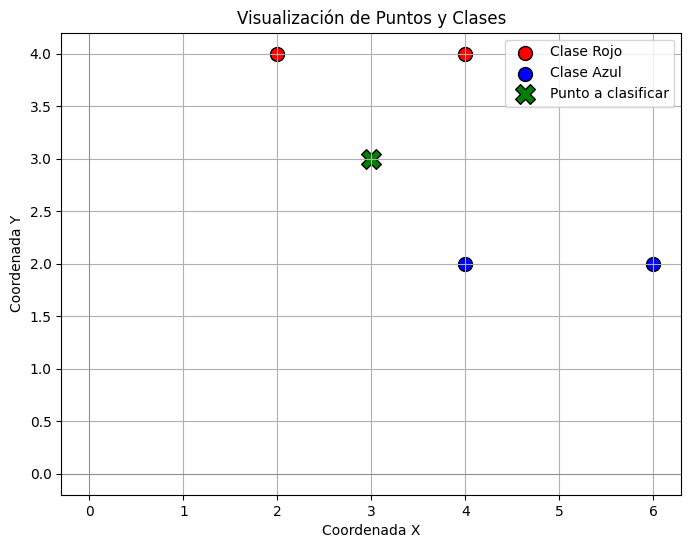

In [5]:
import matplotlib.pyplot as plt

# Separar los puntos por clase para graficarlos con diferentes colores
x_rojo = [X[i][0] for i in range(len(X)) if y[i] == 'Rojo']
y_rojo = [X[i][1] for i in range(len(X)) if y[i] == 'Rojo']

x_azul = [X[i][0] for i in range(len(X)) if y[i] == 'Azul']
y_azul = [X[i][1] for i in range(len(X)) if y[i] == 'Azul']

plt.figure(figsize=(8, 6))

# Graficar los puntos de la clase 'Rojo'
plt.scatter(x_rojo, y_rojo, color='red', label='Clase Rojo', s=100, edgecolors='k')
# Graficar los puntos de la clase 'Azul'
plt.scatter(x_azul, y_azul, color='blue', label='Clase Azul', s=100, edgecolors='k')

# Graficar el punto a clasificar P
plt.scatter(P[0], P[1], color='green', marker='X', s=200, label='Punto a clasificar', edgecolors='k')

# Añadir etiquetas y título
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Visualización de Puntos y Clases')
plt.legend()
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

##Ejercicio 2: k‑NN manual con k = 3

In [6]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])

Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


##Ejercicio 3: Distancia Manhattan

In [7]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


##Ejercicio 4: k‑NN con scikit-learn

In [8]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [9]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

Entrenamiento y predicción

In [10]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


##Ejercicio 5: Impacto de la normalización en k‑NN usando un dataset

###Parte A: k‑NN SIN normalización

In [11]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Dataset
X = np.array([
[25, 8000],
[30, 12000],
[45, 45000],
[50, 60000],
[35, 15000],
[48, 55000]
])

y = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])

nuevo_cliente = np.array([[40, 20000]])

# Modelo k-NN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

# Predicción
modelo.predict(nuevo_cliente)

array(['Alto'], dtype='<U4')

 ¿Qué está pasando aquí?   

 La distancia está dominada casi totalmente por el ingreso

 La edad tiene muy poco impacto   

 El modelo buscará clientes con ingresos cercanos a 20,000



###Parte B: k‑NN CON normalización

In [12]:
from sklearn.preprocessing import StandardScaler

# Escalamiento
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
nuevo_norm = scaler.transform(nuevo_cliente)

# Modelo k-NN
modelo_norm = KNeighborsClassifier(n_neighbors=3)
modelo_norm.fit(X_norm, y)

# Predicción
modelo_norm.predict(nuevo_norm)

array(['Alto'], dtype='<U4')

¿Qué cambia ahora?

Edad e ingreso tienen:

media = 0

desviación estándar = 1

Ambas variables pesan por igual en la distancia

##Ejercicio 6: Empates

In [14]:
X = [(2,2), (2,4), (4,2), (4,4)]
y = ['A', 'B', 'B', 'A']
P = (3,3)

distancias = [(distancia_euclidiana(P, X[i]), y[i]) for i in range(len(X))]
distancias.sort(key=lambda x: x[0])

k = 4
clases = [clase for _, clase in distancias[:k]]

print("Clases vecinas:", clases)

Clases vecinas: ['A', 'B', 'B', 'A']


In [21]:
print(distancias)

[(1.4142135623730951, 'A'), (1.4142135623730951, 'B'), (1.4142135623730951, 'B'), (1.4142135623730951, 'A')]


##Ejercicio 7: Comparación de k

In [20]:
y = np.array(['Alto', 'Alto', 'Bajo', 'Bajo', 'Alto', 'Bajo'])

for k in [1, 3, 5]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_norm, y)
    print(f"k={k} →", modelo.predict(nuevo_norm)[0])

k=1 → Alto
k=3 → Alto
k=5 → Alto


https://moodle.facttria.net/login/index.php